In [1]:
import numpy as np
import torch
from sklearn.metrics.pairwise import polynomial_kernel
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [30]:
def calculate_mmd_reward(generated_features, reference_features, gamma=None):
    """
    A simplified, more reliable MMD-based diversity reward function.
    Uses RBF kernel which is more effective for normalized features.
    
    Args:
        generated_features: Feature matrix for generated images
        reference_features: Feature matrix for reference images
        gamma: RBF kernel bandwidth parameter (None = auto)
    
    Returns:
        reward: Diversity reward value (higher = more diverse/better coverage)
    """
    # Ensure inputs are numpy arrays
    if isinstance(generated_features, torch.Tensor):
        generated_features = generated_features.cpu().numpy()
    if isinstance(reference_features, torch.Tensor):
        reference_features = reference_features.cpu().numpy()
    
    # Normalize features
    gen_norm = np.linalg.norm(generated_features, axis=1, keepdims=True)
    ref_norm = np.linalg.norm(reference_features, axis=1, keepdims=True)
    
    # Avoid division by zero
    gen_norm = np.maximum(gen_norm, 1e-10)
    ref_norm = np.maximum(ref_norm, 1e-10)
    
    generated_features = generated_features / gen_norm
    reference_features = reference_features / ref_norm
    
    # Auto-set gamma if not provided
    if gamma is None:
        # Median heuristic for gamma
        X = np.vstack([generated_features, reference_features])
        pairwise_dists = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
        gamma = 1.0 / np.median(pairwise_dists[pairwise_dists > 0])
    
    # Compute RBF kernel matrices
    from sklearn.metrics.pairwise import rbf_kernel
    
    K_XX = rbf_kernel(generated_features, generated_features, gamma=gamma)
    K_YY = rbf_kernel(reference_features, reference_features, gamma=gamma)
    K_XY = rbf_kernel(generated_features, reference_features, gamma=gamma)
    
    # Sample sizes
    m = generated_features.shape[0]
    n = reference_features.shape[0]
    
    # MMD calculation
    mmd_XX = (np.sum(K_XX) - np.trace(K_XX)) / (m * (m - 1)) if m > 1 else 0
    mmd_YY = (np.sum(K_YY) - np.trace(K_YY)) / (n * (n - 1)) if n > 1 else 0
    mmd_XY = np.sum(K_XY) / (m * n)
    
    # Compute MMD (larger = more different)
    mmd = mmd_XX + mmd_YY - 2 * mmd_XY
    
    # Convert to reward (smaller MMD = better coverage = higher reward)
    # Use exponential transformation for better scaling
    reward = np.exp(-5.0 * mmd)  # Higher = better
    
    return reward

In [42]:
def create_diversity_test_sets(reference_features, n_samples=25, random_seed=42):
    """
    Create test sets with controlled diversity levels for validation.
    
    Args:
        reference_features: Feature matrix for reference images
        n_samples: Number of samples per test set
        random_seed: Random seed for reproducibility
    
    Returns:
        test_sets: Dictionary containing test sets with different diversity levels
    """
    np.random.seed(random_seed)
    
    # 1. High diversity: Random subset of reference images
    high_indices = np.random.choice(len(reference_features), size=n_samples, replace=False)
    high_diversity_features = reference_features[high_indices]
    
    # 2. Medium diversity: K-means clusters (fewer clusters)
    from sklearn.cluster import KMeans
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_seed)
    kmeans.fit(reference_features)
    
    medium_diversity_features = []
    samples_per_cluster = n_samples // n_clusters
    
    for i in range(n_clusters):
        cluster_indices = np.where(kmeans.labels_ == i)[0]
        if len(cluster_indices) == 0:
            continue
            
        # Take multiple samples from each cluster
        selected_indices = np.random.choice(
            cluster_indices, 
            size=min(samples_per_cluster, len(cluster_indices)), 
            replace=False
        )
        medium_diversity_features.append(reference_features[selected_indices])
    
    medium_diversity_features = np.vstack(medium_diversity_features)
    
    # 3. Low diversity: Based on a single cluster
    single_cluster_idx = np.random.randint(0, n_clusters)
    cluster_indices = np.where(kmeans.labels_ == single_cluster_idx)[0]
    
    if len(cluster_indices) >= n_samples:
        # If cluster has enough points, sample from it
        selected_indices = np.random.choice(cluster_indices, size=n_samples, replace=False)
        low_diversity_features = reference_features[selected_indices]
    else:
        # Otherwise, create variants of one point
        center_idx = np.random.choice(cluster_indices)
        center = reference_features[center_idx]
        low_diversity_features = np.array([
            center + np.random.normal(0, 0.05, center.shape) 
            for _ in range(n_samples)
        ])
    
    # 4. No diversity: Copies with minimal noise
    center_idx = np.random.choice(len(reference_features))
    center = reference_features[center_idx]
    no_diversity_features = np.array([
        center + np.random.normal(0, 0.001, center.shape)
        for _ in range(n_samples)
    ])
    
    return {
        'high_diversity': high_diversity_features,
        'medium_diversity': medium_diversity_features,
        'low_diversity': low_diversity_features,
        'no_diversity': no_diversity_features
    }

def test_mmd_reward():
    """
    Test the MMD reward function using pre-created test sets.
    """
    # Load reference features
    data = np.load('reference_clip_features.npz')
    reference_filenames = list(data.files)
    reference_features = np.vstack([data[filename] for filename in reference_filenames])
    
    # Create test sets
    test_sets = create_diversity_test_sets(reference_features, n_samples=25)
    
    # Calculate rewards for each test set
    rewards = {}
    for test_name, test_features in test_sets.items():
        reward = calculate_mmd_reward(test_features, reference_features)
        rewards[test_name] = reward
    
    # Display results
    print("MMD Rewards for different diversity levels:")
    for test_name, reward in rewards.items():
        print(f"{test_name.replace('_', ' ').title()}: {reward:.4f}")
    
    # Verify that rewards follow expected pattern
    expected_order = ['high_diversity', 'medium_diversity', 'low_diversity', 'no_diversity']
    reward_values = [rewards[name] for name in expected_order]
    success = all(reward_values[i] > reward_values[i+1] for i in range(len(reward_values)-1))
    
    print(f"Reward function validation {'PASSED' if success else 'FAILED'}")
    
    # Calculate percentage differences
    high_medium_diff = (rewards['high_diversity'] - rewards['medium_diversity']) / rewards['high_diversity'] * 100
    medium_low_diff = (rewards['medium_diversity'] - rewards['low_diversity']) / rewards['medium_diversity'] * 100
    low_no_diff = (rewards['low_diversity'] - rewards['no_diversity']) / rewards['low_diversity'] * 100
    
    print(f"Percentage differences:")
    print(f"High vs Medium: {high_medium_diff:.2f}%")
    print(f"Medium vs Low:  {medium_low_diff:.2f}%")
    print(f"Low vs None:    {low_no_diff:.2f}%")
    
    # Check if differences meet threshold (15%)
    threshold_passed = (high_medium_diff > 15) and (medium_low_diff > 15) and (low_no_diff > 15)
    print(f"Threshold test: {'PASSED' if threshold_passed else 'FAILED'}")
    
    return {
        'test_sets': test_sets,
        'rewards': rewards,
        'success': success,
        'threshold_passed': threshold_passed
    }

In [43]:
def visualize_diversity_reward(reference_features, test_sets, rewards):
    """
    Visualize different test sets and their diversity rewards in feature space.
    
    Args:
        reference_features: Feature matrix for reference images
        test_sets: Dictionary of feature matrices for different test sets
        rewards: Dictionary of reward values for each test set
    """
    # Combine all features for t-SNE
    all_features = np.vstack([reference_features] + list(test_sets.values()))
    
    # Create labels for coloring
    labels = ['reference'] * len(reference_features)
    for name, features in test_sets.items():
        labels.extend([name] * len(features))
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    projected = tsne.fit_transform(all_features)
    
    # Plot
    plt.figure(figsize=(15, 10))
    
    # Split projected features by label
    start_idx = 0
    for i, (name, features) in enumerate([('reference', reference_features)] + list(test_sets.items())):
        end_idx = start_idx + len(features)
        subset = projected[start_idx:end_idx]
        
        if name == 'reference':
            plt.scatter(subset[:, 0], subset[:, 1], alpha=0.5, label=name)
        else:
            reward_value = rewards[name]
            plt.scatter(subset[:, 0], subset[:, 1], alpha=0.7, label=f"{name}: reward={reward_value:.4f}")
        
        start_idx = end_idx
    
    plt.title("t-SNE Visualization of Feature Space with Diversity Rewards")
    plt.legend()
    plt.savefig("diversity_reward_visualization.png", dpi=300, bbox_inches='tight')
    plt.show()

MMD Rewards for different diversity levels:
High Diversity: 1.1056
Medium Diversity: 1.0880
Low Diversity: 0.2365
No Diversity: 0.0421
Reward function validation PASSED
Percentage differences:
High vs Medium: 1.59%
Medium vs Low:  78.26%
Low vs None:    82.19%
Threshold test: FAILED


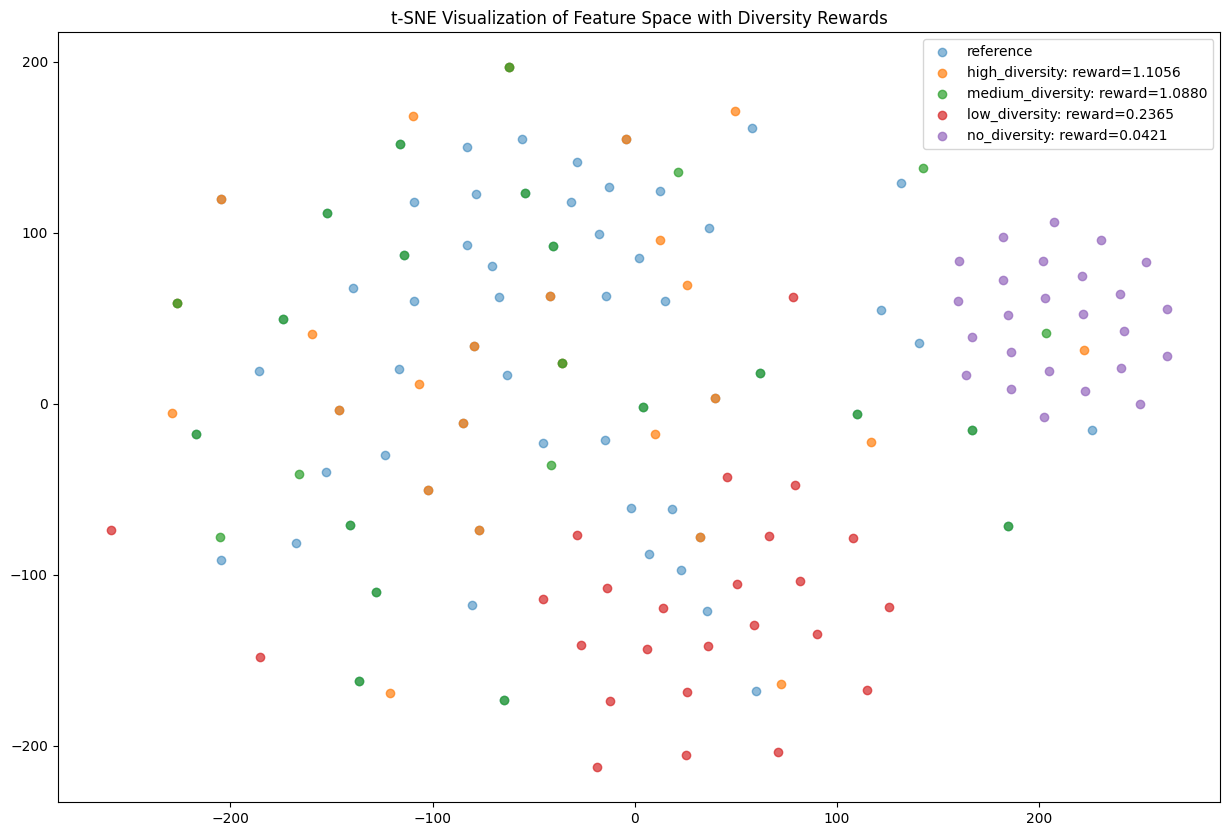

In [44]:
# Run the fixed test
results = test_mmd_reward()

# Visualize the results
data = np.load('reference_clip_features.npz')
reference_filenames = list(data.files)
reference_features = np.vstack([data[filename] for filename in reference_filenames])

# Visualize the results
visualize_diversity_reward(
    reference_features,
    results['test_sets'],
    results['rewards']
)

In [ ]:
def calculate_individual_diversity_rewards(generated_features, reference_features, gamma=None):
    """
    Efficient batched calculation of individual diversity rewards.
    Pre-computes kernel matrices to avoid redundant calculations.
    
    Args:
        generated_features: Feature matrix for generated images (M x feature_dim)
        reference_features: Feature matrix for reference images (N x feature_dim)
        gamma: RBF kernel bandwidth parameter
    
    Returns:
        individual_rewards: Array of diversity rewards for each generated image
    """
    # Ensure inputs are numpy arrays and normalize
    if isinstance(generated_features, torch.Tensor):
        generated_features = generated_features.cpu().numpy()
    if isinstance(reference_features, torch.Tensor):
        reference_features = reference_features.cpu().numpy()
    
    # Normalize features
    gen_norm = np.linalg.norm(generated_features, axis=1, keepdims=True)
    ref_norm = np.linalg.norm(reference_features, axis=1, keepdims=True)
    gen_norm = np.maximum(gen_norm, 1e-10)
    ref_norm = np.maximum(ref_norm, 1e-10)
    generated_features = generated_features / gen_norm
    reference_features = reference_features / ref_norm
    
    # Auto-set gamma if not provided
    if gamma is None:
        X = np.vstack([generated_features, reference_features])
        pairwise_dists = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
        gamma = 1.0 / np.median(pairwise_dists[pairwise_dists > 0])
    
    # For small sets, use simple averaging
    M = len(generated_features)
    if M <= 2:
        overall_reward = calculate_mmd_reward(generated_features, reference_features, gamma)
        return np.ones(M) * overall_reward / M
    
    # PRE-COMPUTE ALL KERNEL MATRICES ONCE
    from sklearn.metrics.pairwise import rbf_kernel
    
    K_GG = rbf_kernel(generated_features, generated_features, gamma=gamma)  # M x M
    K_RR = rbf_kernel(reference_features, reference_features, gamma=gamma)  # N x N  
    K_GR = rbf_kernel(generated_features, reference_features, gamma=gamma)  # M x N
    
    N = len(reference_features)
    
    # Pre-compute reference terms (these don't change)
    ref_ref_sum = np.sum(K_RR) - np.trace(K_RR)
    ref_ref_term = ref_ref_sum / (N * (N - 1)) if N > 1 else 0
    
    # Calculate overall reward with all generated images
    gen_gen_sum = np.sum(K_GG) - np.trace(K_GG)
    gen_gen_term = gen_gen_sum / (M * (M - 1))
    gen_ref_term = np.sum(K_GR) / (M * N)
    overall_mmd = gen_gen_term + ref_ref_term - 2 * gen_ref_term
    overall_reward = np.exp(-5.0 * overall_mmd)
    
    # Calculate individual rewards efficiently using vectorized operations
    individual_rewards = []
    
    for i in range(M):
        # Calculate terms without image i
        # For gen-gen term: subtract row i and column i from the sum
        gen_gen_sum_without_i = (gen_gen_sum 
                                - np.sum(K_GG[i, :])    # subtract row i
                                - np.sum(K_GG[:, i])    # subtract column i  
                                + K_GG[i, i])          # add back diagonal (subtracted twice)
        
        gen_gen_term_without_i = gen_gen_sum_without_i / ((M-1) * (M-2)) if M > 2 else 0
        
        # For gen-ref term: subtract row i
        gen_ref_sum_without_i = np.sum(K_GR) - np.sum(K_GR[i, :])
        gen_ref_term_without_i = gen_ref_sum_without_i / ((M-1) * N)
        
        # Calculate MMD without image i
        mmd_without_i = gen_gen_term_without_i + ref_ref_term - 2 * gen_ref_term_without_i
        reward_without_i = np.exp(-5.0 * mmd_without_i)
        
        # Individual contribution
        marginal_contribution = overall_reward - reward_without_i
        individual_rewards.append(marginal_contribution)
    
    # Convert to array and normalize if needed
    individual_rewards = np.array(individual_rewards)
    if np.min(individual_rewards) < 0:
        individual_rewards -= np.min(individual_rewards)
    
    return individual_rewards


# def calculate_mmd_reward(generated_features, reference_features, gamma):
#     """Helper function to calculate MMD reward from pre-computed features"""
#     # This is just the core of your existing function
#     from sklearn.metrics.pairwise import rbf_kernel
    
#     K_XX = rbf_kernel(generated_features, generated_features, gamma=gamma)
#     K_YY = rbf_kernel(reference_features, reference_features, gamma=gamma)
#     K_XY = rbf_kernel(generated_features, reference_features, gamma=gamma)
    
#     m = generated_features.shape[0]
#     n = reference_features.shape[0]
    
#     mmd_XX = (np.sum(K_XX) - np.trace(K_XX)) / (m * (m - 1)) if m > 1 else 0
#     mmd_YY = (np.sum(K_YY) - np.trace(K_YY)) / (n * (n - 1)) if n > 1 else 0
#     mmd_XY = np.sum(K_XY) / (m * n)
    
#     mmd = mmd_XX + mmd_YY - 2 * mmd_XY
#     return np.exp(-5.0 * mmd)